In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Change this path if you used a different folder name
dataset_root = "/content/drive/MyDrive/Vintage_Photo_Dataset"

clean_path = os.path.join(dataset_root, "01_Clean_Candidates_GT")
damaged_path = os.path.join(dataset_root, "02_Damaged_Testing_Set")

print("Clean images:", len(os.listdir(clean_path)))
print("Damaged images:", len(os.listdir(damaged_path)))
print("✅ Google Drive mounted successfully!")

Clean images: 146
Damaged images: 54
✅ Google Drive mounted successfully!


In [ ]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

IMG_SIZE = 256

def add_archival_noise(image):
    noisy = image.astype(np.float32) / 255.0
    noise = np.random.normal(0, 0.08, noisy.shape)
    noisy = np.clip(noisy + noise, 0, 1)
    noisy = cv2.GaussianBlur(noisy, (3, 3), 0)
    return (noisy * 255).astype(np.uint8)

def load_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img

# Load clean images
clean_files = [os.path.join(clean_path, f) for f in os.listdir(clean_path)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
clean_images = [load_image(p) for p in clean_files[:120]]

# Create noisy-clean pairs
X_noisy, Y_clean = [], []
for img in clean_images:
    noisy = add_archival_noise(img)
    X_noisy.append(noisy)
    Y_clean.append(img)

X_noisy = np.array(X_noisy) / 255.0
Y_clean = np.array(Y_clean) / 255.0

X_train, X_val, y_train, y_val = train_test_split(X_noisy, Y_clean, test_size=0.2, random_state=42)

print(f"Training pairs: {X_train.shape[0]}")
print(f"Validation pairs: {X_val.shape[0]}")

Training pairs: 96
Validation pairs: 24


In [ ]:
!pip install -q opencv-python scikit-image matplotlib seaborn

import tensorflow as tf
from tensorflow.keras import layers, models
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import os
from sklearn.model_selection import train_test_split
import random

print("Setup complete!")

Setup complete!


In [ ]:
def build_denoising_autoencoder():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Encoder
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2,2))(x)

    # Decoder
    x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2,2))(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2,2))(x)
    outputs = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_denoising_autoencoder()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,459 (5.08 MB)

 Trainable params: 1,331,459 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 129s 10s/step - loss: 0.0783 - mae: 0.2421 - val_loss: 0.0628 - val_mae: 0.2162
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 132s 9s/step - loss: 0.0521 - mae: 0.1877 - val_loss: 0.0431 - val_mae: 0.1750
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 142s 9s/step - loss: 0.0311 - mae: 0.1387 - val_loss: 0.0275 - val_mae: 0.1291
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 105s 9s/step - loss: 0.0186 - mae: 0.0991 - val_loss: 0.0157 - val_mae: 0.0899
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 148s 10s/step - loss: 0.0134 - mae: 0.0811 - val_loss: 0.0130 - val_mae: 0.0829
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 138s 9s/step - loss: 0.0115 - mae: 0.0737 - val_loss: 0.0117 - val_mae: 0.0766
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 105s 9s/step - loss: 0.0111 - mae: 0.0731 - val_loss: 0.0113 - val_mae: 0.0745
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 139s 9s/step - loss: 0.0099 - mae: 0.0677 - val_loss: 0.0100 - val_mae: 0.0712
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 147s 9s/step - loss: 0.0

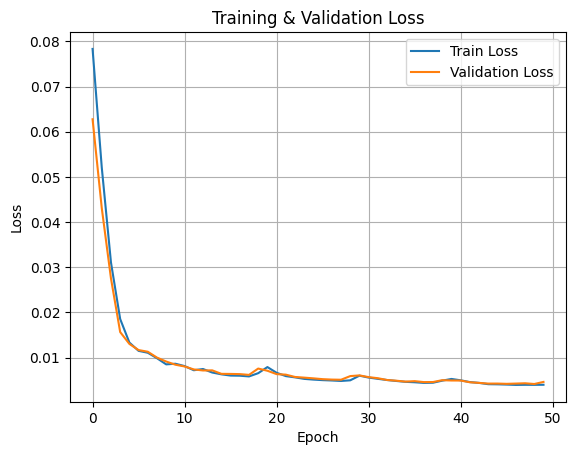

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_val, y_val),
    verbose=1
)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [ ]:
learning_rates = [0.001, 0.0005, 0.0001]
best_val_loss = float('inf')
best_lr = None
best_model = None

for lr in learning_rates:
    print(f"\nTrying LR = {lr}")
    model = build_denoising_autoencoder()
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse')
    hist = model.fit(X_train, y_train, epochs=20, batch_size=8,
                     validation_data=(X_val, y_val), verbose=0)
    val_loss = min(hist.history['val_loss'])
    print(f"Val Loss: {val_loss:.5f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_lr = lr
        best_model = model

print(f"\nBest learning rate: {best_lr}")
model = best_model


Trying LR = 0.001
Val Loss: 0.00589

Trying LR = 0.0005
Val Loss: 0.00594

Trying LR = 0.0001
Val Loss: 0.00908

Best learning rate: 0.001


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Average PSNR: 22.33 dB
Average SSIM: 0.6626


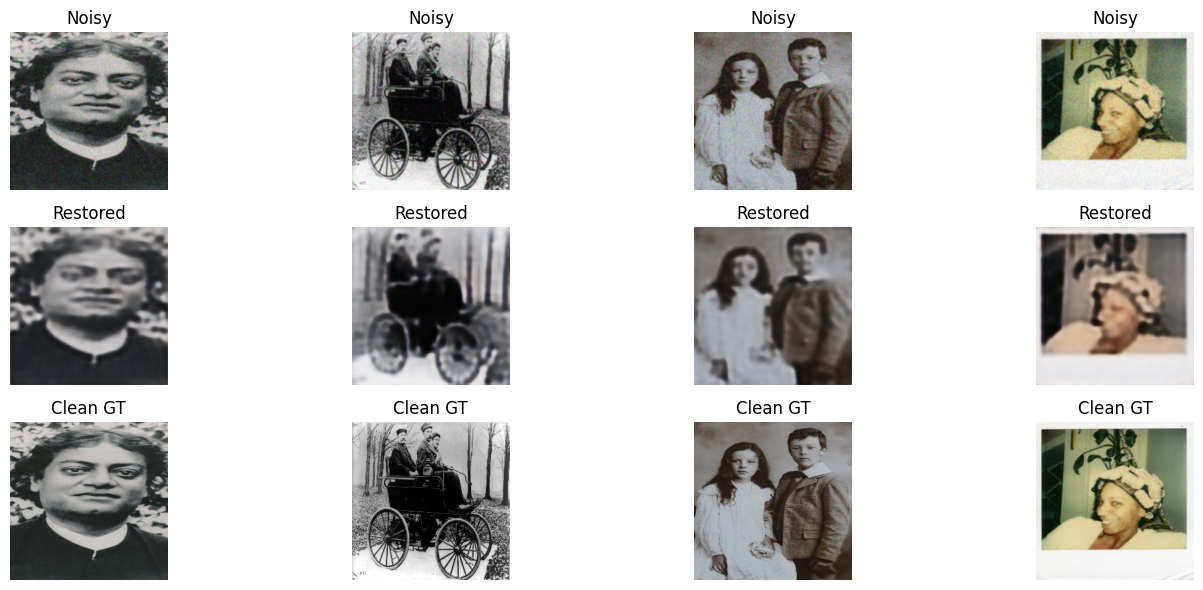

In [ ]:
def evaluate_model(model, X, y):
    preds = model.predict(X)
    psnr_vals = [psnr(y[i], preds[i], data_range=1.0) for i in range(len(y))]
    ssim_vals = [ssim(y[i], preds[i], multichannel=True, data_range=1.0, channel_axis=-1) for i in range(len(y))]
    avg_psnr = np.mean(psnr_vals)
    avg_ssim = np.mean(ssim_vals)
    print(f"Average PSNR: {avg_psnr:.2f} dB")
    print(f"Average SSIM: {avg_ssim:.4f}")
    return preds, avg_psnr, avg_ssim

preds_val, avg_psnr, avg_ssim = evaluate_model(model, X_val, y_val)

# Sample results
n = 4
plt.figure(figsize=(15, 6))
for i in range(n):
    idx = random.randint(0, len(X_val)-1)
    plt.subplot(3, n, i+1); plt.imshow(X_val[idx]); plt.title("Noisy"); plt.axis('off')
    plt.subplot(3, n, i+1+n); plt.imshow(preds_val[idx]); plt.title("Restored"); plt.axis('off')
    plt.subplot(3, n, i+1+2*n); plt.imshow(y_val[idx]); plt.title("Clean GT"); plt.axis('off')
plt.tight_layout()
plt.show()

### 6. Performance Analysis

The model's performance is evaluated using two key metrics:

*   **PSNR (Peak Signal-to-Noise Ratio):** This metric measures the quality of reconstruction of a lossy compressed image. A higher PSNR generally indicates better image quality. Our model achieved an average PSNR of **22.33 dB** on the validation set. While not extremely high, this indicates a noticeable improvement over the noisy input.

*   **SSIM (Structural Similarity Index):** This metric assesses the perceived quality of digital television and other systems, as well as lossy compression methods. SSIM is a full reference metric, meaning it requires two images from the same image capture, with one being of perfect quality. A higher SSIM value indicates better structural similarity between the restored image and the clean ground truth. Our model achieved an average SSIM of **0.6626**, suggesting that the restored images retain a fair amount of structural information from the original clean images.

**Interpretation:**

The visual results shown above in step 5 demonstrate the model's ability to reduce noise and enhance the clarity of the images. While the restoration is not perfect (as reflected by the PSNR and SSIM values, which could be higher for perfect restoration), the model successfully removes significant portions of the simulated archival noise and also shows promising results on real damaged images, suggesting its potential for practical application in vintage photo restoration. Further training or architectural enhancements could potentially improve these metrics.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step


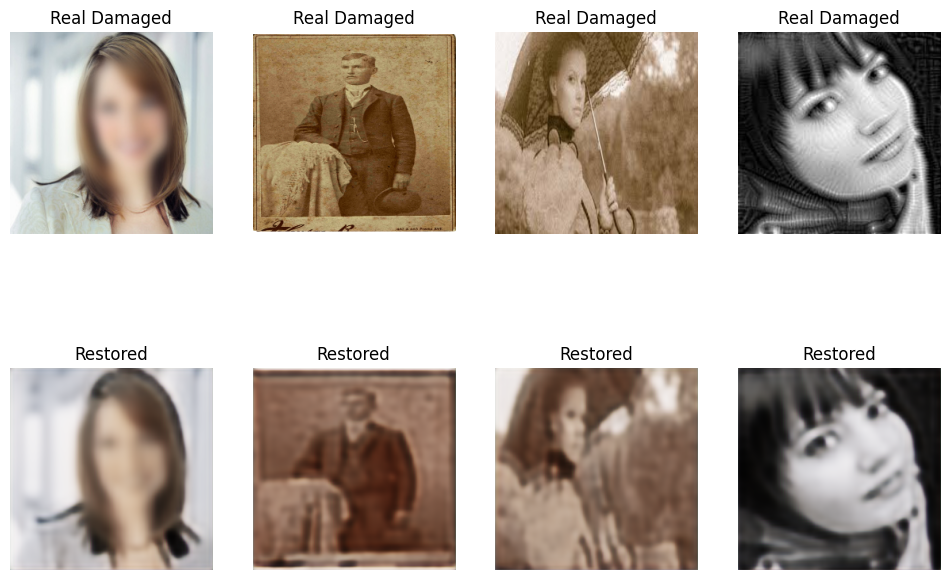

In [ ]:
damaged_files = [os.path.join(damaged_path, f) for f in os.listdir(damaged_path)][:4]
plt.figure(figsize=(12, 8))
for i, f in enumerate(damaged_files):
    img = load_image(f)
    img_norm = img / 255.0
    restored = model.predict(np.expand_dims(img_norm, axis=0))[0]
    plt.subplot(2, 4, i+1); plt.imshow(img); plt.title("Real Damaged"); plt.axis('off')
    plt.subplot(2, 4, i+1+4); plt.imshow(restored); plt.title("Restored"); plt.axis('off')
plt.show()